In [1]:
def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=False)
    return x_test, t_test

def init_network():
    with open("dataset/sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)
    return network

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c)  # Prevent overflow by subtracting the max
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a

    return y

def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y

오분류된 데이터 번호: 8
정답: 5
예측: 6


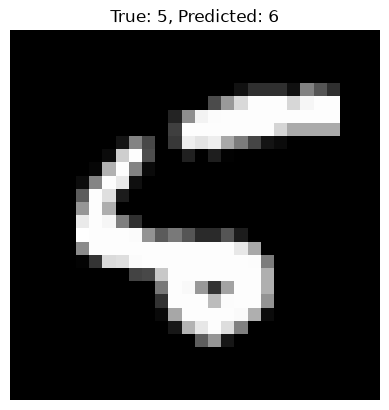

Accuracy:0.9352


In [3]:
import sys, os, pickle
sys.path.append(os.pardir)  # Add parent directory to the path
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from PIL import Image

x, t = get_data()
network = init_network()

accuracy_cnt = 0
first_error_shown = False
for i in range(len(x)):
    y = predict(network, x[i])
    p = np.argmax(y)  # Get the index of the highest probability
    if p == t[i]:
        accuracy_cnt += 1

    elif not first_error_shown:
        print("오분류된 데이터 번호:", i)
        print("정답:", t[i])
        print("예측:", p)

        img = x[i].reshape(28, 28)

        plt.imshow(img, cmap='gray')
        plt.title(f"True: {t[i]}, Predicted: {p}")
        plt.axis('off')
        plt.show()

        first_error_shown = True

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))